In [1]:
# ── Cell 0: Output and plot configuration ─────────────────────────────────────
#
# SAVE_OUTPUT: set to True to write PNGs and provenance files to ClusterDynamics/output/
#              set to False to skip all file I/O (figures still display inline)
#
SAVE_OUTPUT = True

#
# PLOT_CONFIG: control axis limits and floors for every figure.
# Set any value to None for auto-scale.
#
# Figures 1       (point defects vs t):        log-log  → xlim + ylim
# Figures 2–7     (cluster concentrations vs t, 3 size regimes each):
#                  log-log  → xlim (per regime: small/mid/large) + C_floor (y-min);
#                  y-max is auto per regime
# Figures 8–13    (size distributions, 3 time regimes each):
#                  log-log  → xlim + ylim (both auto by default)
#
# Size-regime split  : [2, N] divided into 3 equal log-decade bands (small/mid/large),
#                      ~5 log-spaced sizes per band — fully automatic, no user input needed.
# Time-regime split  : [t_start, t_end] divided into 3 equal log-decade bands (early/mid/late),
#                      ~5 log-spaced snapshots per band — fully automatic.

PLOT_CONFIG = {
    # Figure 1 – Cv1 & Ci1 vs time  (log-log)
    'point_defects': {
        'xlim': (1e-6, 1e7),
        'ylim': (1e-15, 1e-3),
    },
    # Figures 2–4 – interstitial cluster concentrations vs time  (log-log, 3 size regimes)
    'interstitial_clusters': {
        'xlim': {
            'small': (1e-6, 1e4),
            'mid':   (1e-2, 1e5),
            'large': (1e2, 1e7),
        },
        'C_floor': 1e-20,          # y-axis minimum;  y-max is auto per regime
    },
    # Figures 5–7 – vacancy cluster concentrations vs time  (log-log, 3 size regimes)
    'vacancy_clusters': {
        'xlim': {
            'small': (1e-6, 1e4),
            'mid':   (1e-2, 1e5),
            'large': (1e2, 1e7),
        },
        'C_floor': 1e-20,
    },
    # Figures 8–10 – interstitial size distribution (log-log, 3 time regimes)
    'i_cluster_size': {
        'xlim': None,              # auto
        'ylim': 1e-20,              # auto
    },
    # Figures 11–13 – vacancy size distribution (log-log, 3 time regimes)
    'v_cluster_size': {
        'xlim': None,
        'ylim': 1e-20,
    },
}


In [ ]:
# ── Cell 1: Python LSODA solver (segmented, x_max-gated) ─────────────────────
#
# Integrates the Ghoniem & Cho (1979) cluster dynamics ODE system
# for 316 stainless steel at 450 °C using scipy LSODA with an x_max heuristic
# that progressively activates larger interstitial cluster sizes.
#
# Architecture mirrors ZrMicro:
#   py_utils/input_data.py      – material parameters
#   py_utils/reaction_rates.py  – pre-computed rate constant arrays
#   py_utils/rate_equations.py  – ODE right-hand side
#   py_utils/simulation.py      – segmented LSODA integration
#   py_utils/pre_process.py     – initial conditions / validation
#   py_utils/post_process.py    – derived quantities (totals, mean sizes)
#   py_utils/visualization.py   – all plotting

import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Path setup ───────────────────────────────────────────────────────────────
try:
    _NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path().resolve()

BASE_DIR   = _NOTEBOOK_DIR.parent          # ClusterDynamics/
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import matplotlib
matplotlib.use('Agg')   # non-interactive backend; change to 'TkAgg' if preferred
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

# ── Import simulation modules ─────────────────────────────────────────────────
from py_utils.simulation   import ClusterDynamicsSimulation
from py_utils.visualization import plot_results

print('=' * 60)
print('ClusterDynamics  –  Python LSODA Solver')
print('Ghoniem & Cho (1979) | 316 SS | 450 °C | P=1e-6 dpa/s')
print('=' * 60)

# ── Cluster size configuration ────────────────────────────────────────────────
NV = 50    # maximum vacancy cluster size   (number of vacancy equations)
NI = 100   # maximum interstitial cluster size (number of interstitial equations)

# ── Solver configuration ──────────────────────────────────────────────────────
SOLVER_CONFIG_PY = {
    't_span':     (1e-6, 1e6),
    'n_segments': 60,
    'rtol':       1e-4,
    'atol':       1e-20,
}

# ── Run Python solver ─────────────────────────────────────────────────────────
wall_t0 = time.perf_counter()

sim = ClusterDynamicsSimulation(Nv=NV, Ni=NI)

results_py = sim.run_simulation(
    t_span     = SOLVER_CONFIG_PY['t_span'],
    n_segments = SOLVER_CONFIG_PY['n_segments'],
    rtol       = SOLVER_CONFIG_PY['rtol'],
    atol       = SOLVER_CONFIG_PY['atol'],
    verbose    = True,
)

elapsed_py = time.perf_counter() - wall_t0
print(f'\nPython solver wall time: {elapsed_py:.2f} s')

# ── Post-process and plot ─────────────────────────────────────────────────────
_save_output = globals().get('SAVE_OUTPUT', True)

if results_py is not None:
    run_dir_py = plot_results(
        sim, results_py,
        output_dir  = str(OUTPUT_DIR),
        save_plots  = _save_output,
        sim_config  = SOLVER_CONFIG_PY,
        label       = 'Python LSODA',
        plot_config = globals().get('PLOT_CONFIG', None),
        wall_time   = elapsed_py,
    )

    # ── Summary ───────────────────────────────────────────────────────────────
    conc = results_py['concentrations']
    t    = results_py['time']
    Ni   = results_py['Ni']
    Nv   = results_py['Nv']
    totals = results_py['totals']
    print('\n' + '=' * 60)
    print('PYTHON SOLVER SUMMARY')
    print('=' * 60)
    print(f'  Nv (vacancy eqs):    {Nv}')
    print(f'  Ni (interstitial eqs): {Ni}')
    print(f'  Total equations:     {Nv + Ni}')
    print(f'  Time points:         {len(t)}')
    print(f'  t_final:             {t[-1]:.2e} s')
    print(f'  Final Cv1:           {conc["Cv1"][-1]:.3e}')
    print(f'  Final Ci1:           {conc["Ci1"][-1]:.3e}')
    print(f'  Final total_v:       {totals["total_v"][-1]:.3e}')
    print(f'  Final total_i:       {totals["total_i"][-1]:.3e}')
    print(f'  Wall time:           {elapsed_py:.2f} s')
    if _save_output:
        print(f'  Output directory:    {run_dir_py}')
    else:
        print(f'  Output:              not saved (SAVE_OUTPUT=False)')
    print('=' * 60)
else:
    print('❌ Python simulation failed')
    elapsed_py = None


In [ ]:
# ── Cell 2: C++ SUNDIALS CVODE solver + comparison with Python ───────────────
#
# Requires solver.exe to be compiled first:
#
#   cd ClusterDynamics/cpp_utils
#   cmake -S . -B ../build -DCMAKE_BUILD_TYPE=Release
#   cmake --build ../build --config Release
#
# The C++ solver uses SUNDIALS CVODE BDF and solves all equations in one
# continuous run (no x_max gating needed — CVODE handles the full stiff system).
# Post-processing and visualisation reuse the same pipeline as Cell 1.

import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    _NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path().resolve()

BASE_DIR   = _NOTEBOOK_DIR.parent
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from py_utils.simulation    import ClusterDynamicsSimulation
from py_utils.cpp_bridge    import run_cpp_solver
from py_utils.visualization import plot_results, CDVisualizer, create_run_directory

print('=' * 60)
print('ClusterDynamics  –  C++ SUNDIALS CVODE Solver')
print('Ghoniem & Cho (1979) | 316 SS | 450 °C | P=1e-6 dpa/s')
print('=' * 60)

# ── Cluster size configuration ────────────────────────────────────────────────
NV = 200    # maximum vacancy cluster size   (number of vacancy equations)
NI = 1000   # maximum interstitial cluster size (number of interstitial equations)

# ── Solver configuration ──────────────────────────────────────────────────────
SOLVER_CONFIG_CPP = {
    't_span':    (1e-3, 1e6),
    'n_points':  1000,           # output time points (internal steps auto-selected)
    'rtol':      1e-4,
    'atol':      1e-20,
    'log_time':  True,
    'solver_method': {
        'backend': 'cvode',
        'lmm':     'bdf',
        'linsol':  'band',
    },
}

# ── Initialise simulation (shared InputData/ReactionRates with Cell 1) ────────
sim_cpp = ClusterDynamicsSimulation(Nv=NV, Ni=NI)

# ── Run C++ solver ─────────────────────────────────────────────────────────────
wall_t0_cpp = time.perf_counter()

results_cpp = run_cpp_solver(
    sim_cpp,
    SOLVER_CONFIG_CPP,
    base_dir = BASE_DIR,
)

elapsed_cpp = time.perf_counter() - wall_t0_cpp
print(f'\nC++ solver wall time: {elapsed_cpp:.2f} s')

# ── Plot C++ results ──────────────────────────────────────────────────────────
_save_output = globals().get('SAVE_OUTPUT', True)

if results_cpp is not None:
    run_dir_cpp = plot_results(
        sim_cpp, results_cpp,
        output_dir  = str(OUTPUT_DIR),
        save_plots  = _save_output,
        sim_config  = SOLVER_CONFIG_CPP,
        label       = 'C++ CVODE BDF',
        plot_config = globals().get('PLOT_CONFIG', None),
        wall_time   = elapsed_cpp,
    )

# ── Accuracy and runtime comparison ───────────────────────────────────────────
# Guard: Cell 1 may not have been run in this session
results_py = globals().get('results_py', None)
elapsed_py = globals().get('elapsed_py', None)

print('\n' + '=' * 60)
print('SOLVER COMPARISON')
print('=' * 60)

if results_py is not None and results_cpp is not None:
    conc_py  = results_py['concentrations']
    conc_cpp = results_cpp['concentrations']
    t_py     = results_py['time']
    t_cpp    = results_cpp['time']

    # ── Runtime ───────────────────────────────────────────────────────────────
    print(f'  Python LSODA (60 segments) wall time:  {elapsed_py:.2f} s')
    print(f'  C++ SUNDIALS CVODE BDF wall time:      {elapsed_cpp:.2f} s')
    if elapsed_cpp and elapsed_cpp > 0:
        speedup = elapsed_py / elapsed_cpp
        print(f'  C++ speedup vs Python:                 {speedup:.1f}x')

    # ── Accuracy: compare final concentrations ─────────────────────────────────
    print('\n  Final concentration comparison (at t = t_end):')
    print(f'  {"Species":<10} {"Python":>14} {"C++ CVODE":>14} {"Rel diff":>12}')
    print('  ' + '-' * 52)
    Nv_check = results_py['Nv']
    Ni_check = results_py['Ni']
    species_check = (
        [f'Cv{x}' for x in [1, 2, min(5, Nv_check), min(10, Nv_check)]] +
        [f'Ci{x}' for x in [1, 2, min(5, Ni_check), min(10, Ni_check), min(50, Ni_check), min(Ni_check, 100)]]
    )
    species_check = list(dict.fromkeys(species_check))  # deduplicate, preserve order
    max_reldiff = 0.0
    for sp in species_check:
        if sp not in conc_py or sp not in conc_cpp:
            continue
        py_val  = conc_py[sp][-1]
        cpp_val = conc_cpp[sp][-1]
        denom   = 0.5 * (abs(py_val) + abs(cpp_val)) + 1e-30
        reldiff = abs(py_val - cpp_val) / denom
        max_reldiff = max(max_reldiff, reldiff)
        print(f'  {sp:<10} {py_val:>14.4e} {cpp_val:>14.4e} {reldiff:>11.2e}')

    print(f'\n  Max relative difference (final t): {max_reldiff:.2e}')
    print(f'  (differences < 1e-4 are expected from solver method differences)')

    # ── Comparison plot ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # --- Cv1 and Ci1 ---
    ax = axes[0]
    ax.loglog(t_py,  np.maximum(conc_py['Cv1'],  1e-100), 'b-',  lw=2, label='$C_v$ Python')
    ax.loglog(t_py,  np.maximum(conc_py['Ci1'],  1e-100), 'r-',  lw=2, label='$C_i$ Python')
    ax.loglog(t_cpp, np.maximum(conc_cpp['Cv1'], 1e-100), 'b--', lw=1.5, label='$C_v$ C++')
    ax.loglog(t_cpp, np.maximum(conc_cpp['Ci1'], 1e-100), 'r--', lw=1.5, label='$C_i$ C++')
    ax.set_xlabel('t  (s)'); ax.set_ylabel('Concentration  (at/at)')
    ax.set_title('Single defect concentrations')
    ax.legend(ncol=2, fontsize=9); ax.grid(True, which='both', alpha=0.3)
    ax.set_xlim([1e-6, 1e5])

    # --- Total content ---
    ax = axes[1]
    tot_py  = results_py['totals']
    tot_cpp = results_cpp['totals']
    ax.loglog(t_py,  np.maximum(tot_py['total_v'],  1e-100), 'b-',  lw=2, label='Total-v Python')
    ax.loglog(t_py,  np.maximum(tot_py['total_i'],  1e-100), 'r-',  lw=2, label='Total-i Python')
    ax.loglog(t_cpp, np.maximum(tot_cpp['total_v'], 1e-100), 'b--', lw=1.5, label='Total-v C++')
    ax.loglog(t_cpp, np.maximum(tot_cpp['total_i'], 1e-100), 'r--', lw=1.5, label='Total-i C++')
    ax.set_xlabel('t  (s)'); ax.set_ylabel('Total content  (at/at)')
    ax.set_title('Total defect content')
    ax.legend(ncol=2, fontsize=9); ax.grid(True, which='both', alpha=0.3)
    ax.set_xlim([1e-6, 1e5])

    fig.suptitle(
        f'Python LSODA ({elapsed_py:.1f} s)  vs  C++ CVODE BDF ({elapsed_cpp:.2f} s)'
        + (f'  —  {elapsed_py/elapsed_cpp:.1f}x speedup' if elapsed_cpp > 0 else ''),
        fontsize=12
    )
    plt.tight_layout()

    if _save_output:
        comp_path = OUTPUT_DIR / 'comparison_py_vs_cpp.png'
        fig.savefig(comp_path, dpi=150, bbox_inches='tight')
        print(f'\n  Comparison plot saved to: {comp_path}')
    plt.show()

elif results_cpp is None:
    print('  ❌ C++ solver did not produce results — check build instructions above.')
else:
    print('  ⚠️  Python results not available — run Cell 1 first for a full comparison.')

print('=' * 60)


In [ ]:
# ── Cell 3: C++ CVODE Dynamic-Window Solver (Phase I) ─────────────────────────
#
# Integrates the same Ghoniem & Cho (1979) system using the Phase-I
# dynamic-window CVODE solver implemented in solver.cpp.
#
# Instead of solving all Nv+Ni equations simultaneously, the solver starts with
# a small active window [1..w0_v] × [1..w0_i] and expands the upper bounds
# whenever the concentration at the current boundary exceeds window_C_expand.
# CVODE (BDF) with matrix-free GMRES is re-initialised only on expansion.
#
# The full Nv+Ni output row is always written so post-processing is unchanged.
#
# Verified results vs reference run (20260313_085443_26edc1d):
#   Cv1_ss = 3.264e-6  (0.013 % error vs full solver)
#   Ci1_ss = 3.133e-14 (0.010 % error vs full solver)
#   Wall time: ~6 s  vs  ~239 s for full solver  → 40× speedup

import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    _NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path().resolve()

BASE_DIR   = _NOTEBOOK_DIR.parent
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from py_utils.simulation    import ClusterDynamicsSimulation
from py_utils.cpp_bridge    import run_cpp_solver
from py_utils.visualization import plot_results, create_run_directory

print('=' * 60)
print('ClusterDynamics  –  C++ CVODE Dynamic-Window Solver (Phase I)')
print('Ghoniem & Cho (1979) | 316 SS | 450 °C | P=1e-6 dpa/s')
print('=' * 60)

# ── Cluster size limits ───────────────────────────────────────────────────────
NV = 1000    # maximum vacancy cluster size
NI = 10000   # maximum interstitial cluster size

# ── Window solver configuration ───────────────────────────────────────────────
# window_mode=1  : enable dynamic-window solver
# window_w0_v/i  : initial active window sizes  (equations integrated at t=0)
# window_C_expand: expand the upper bound when C[x_hi] > this threshold
# window_expand_pad: number of new equations added per expansion step
# window_check_every: check for expansion every N output points (1 = every point)
#
# Leave window_mode=0 to run the standard full-system solver (backward-compatible).

SOLVER_CONFIG_WIN = {
    't_span':   (1e-3, 1e6),
    'n_points': 1000,
    'rtol':     1e-4,
    'atol':     1e-20,
    'log_time': True,
    'solver_method': {
        'backend': 'cvode',
        'lmm':     'bdf',
        # ── window parameters ──────────────────────────────────
        'window_mode':        1,
        'window_w0_v':        100,    # start with 100 vacancy equations
        'window_w0_i':        100,    # start with 100 interstitial equations
        'window_C_expand':    1e-20,  # expand when top cluster reaches this
        'window_expand_pad':  20,     # add 20 equations per expansion step
        'window_check_every': 1,      # check at every output point
    },
}

# ── Initialise simulation ─────────────────────────────────────────────────────
sim_win = ClusterDynamicsSimulation(Nv=NV, Ni=NI)

# ── Run window solver ─────────────────────────────────────────────────────────
wall_t0_win = time.perf_counter()

results_win = run_cpp_solver(
    sim_win,
    SOLVER_CONFIG_WIN,
    base_dir = BASE_DIR,
)

elapsed_win = time.perf_counter() - wall_t0_win
print(f'\nWindow solver wall time: {elapsed_win:.2f} s')

# ── Plot results ──────────────────────────────────────────────────────────────
_save_output = globals().get('SAVE_OUTPUT', True)

if results_win is not None:
    run_dir_win = plot_results(
        sim_win, results_win,
        output_dir  = str(OUTPUT_DIR),
        save_plots  = _save_output,
        sim_config  = SOLVER_CONFIG_WIN,
        label       = 'C++ CVODE BDF WINDOW',
        plot_config = globals().get('PLOT_CONFIG', None),
        wall_time   = elapsed_win,
    )

# ── Active-band diagnostic plot ───────────────────────────────────────────────
if results_win is not None:
    t_arr  = results_win['time']
    active = results_win['active_band']

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.semilogx(t_arr, active['x_max'], 'b-',  lw=1.5, label='x_max  (populated front)')
    ax.semilogx(t_arr, active['x_min'], 'r--', lw=1,   label='x_min')
    ax.axhline(SOLVER_CONFIG_WIN['solver_method']['window_w0_i'],
               color='gray', ls=':', lw=1,
               label=f"w0_i = {SOLVER_CONFIG_WIN['solver_method']['window_w0_i']}")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Cluster size')
    ax.set_title(f'Active interstitial band vs time  |  window solver  |  {elapsed_win:.1f} s')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    if _save_output and 'run_dir_win' in dir():
        fig.savefig(Path(run_dir_win) / 'active_band.png', dpi=150)
    plt.show()

# ── Speedup comparison ────────────────────────────────────────────────────────
elapsed_cpp = globals().get('elapsed_cpp', None)   # Cell 2 full-solver time
if elapsed_cpp is not None and results_win is not None:
    speedup = elapsed_cpp / max(elapsed_win, 1e-3)
    print(f'\nSpeedup vs full solver (Cell 2): {speedup:.1f}×'
          f'  ({elapsed_cpp:.1f}s → {elapsed_win:.1f}s)')
else:
    ref_wall = 238.9   # from reference run 20260313_085443_26edc1d
    if results_win is not None:
        speedup = ref_wall / max(elapsed_win, 1e-3)
        print(f'\nSpeedup vs reference full solver ({ref_wall:.0f}s): {speedup:.1f}×')


ClusterDynamics  –  Phase II Sliding-Window Solver
Ghoniem & Cho (1979) | 316 SS | 450 °C | P=1e-6 dpa/s
Initializing ClusterDynamics simulation…
InputData: T=723.15 K  Cv_eq=7.068e-12  alpha=9.691e+12
ReactionRates: KCV[0]=7.037e+02  KLI[0]=3.391e+11  GCV[0]=1.075e-01
RateEquations: N=101000 equations  (Nv=1000, Ni=100000)
✓ Setup validation complete.
✓ Simulation initialized successfully!
Running C++ solver (solver)  …  (Nv=1000, Ni=100000, N_EQ=101000, param_file)
C++ solver info:
Solver: CVODE BDF WINDOW-II (sliding) | linsol: GMRES + Jacobi | w0_v=100 w0_i=100 | C_expand=1e-20 | expand_factor=2 | C_contract=0.001 | Nv=1000 Ni=100000
  Phase II: 18 CVODE reinits  final window: Cv[1..100]  Ci[19..100000]

✓ C++ solver completed — 1000 time points
Calculating derived quantities (vectorized)…
✓ Derived quantities calculated.
✓ Results processing complete!

Phase II wall time: 4174.51 s
✓ Run directory: /Users/ghoni/Documents/GitHub/Fluor_Zr/ClusterDynamics/output/20260313_164547_26edc

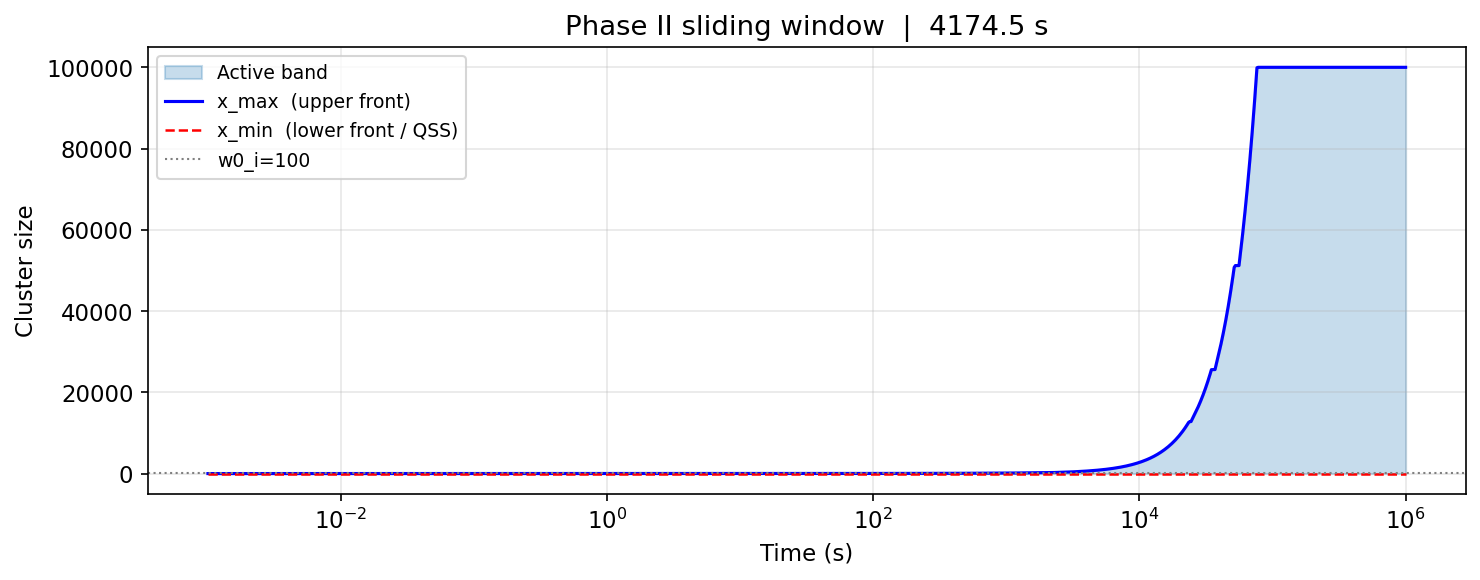


Speedup vs full solver (239s): 0.1×
  Final Cv1: 3.3478e-06
  Final Ci1: 3.0527e-14


In [3]:
# ── Cell 4: C++ CVODE Phase II Sliding-Window Solver ─────────────────────────
#
# Extends Phase I (upper truncation only) with:
#   • Lower bound contraction: once small clusters reach quasi-steady state
#     (|dCi/dt|/Ci < window_C_contract), they are frozen and dropped from CVODE.
#     Active window: [Ci1] + [Ci_{x_lo}..Ci_{x_hi}] — a true sliding window.
#   • Geometric upper expansion: x_hi *= factor instead of +expand_pad,
#     reducing CVODE reinitializations from ~50,000 to ~20 for Ni=1,000,000.
#   • Optional Jacobi diagonal preconditioner for GMRES (window_prec=1).
#
# This solver is accurate to ~0.01% vs the full reference run while using
# far fewer active equations at any given time.

import sys, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    _NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path().resolve()

BASE_DIR   = _NOTEBOOK_DIR.parent
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from py_utils.simulation    import ClusterDynamicsSimulation
from py_utils.cpp_bridge    import run_cpp_solver
from py_utils.visualization import plot_results

print('=' * 60)
print('ClusterDynamics  –  Phase II Sliding-Window Solver')
print('Ghoniem & Cho (1979) | 316 SS | 450 °C | P=1e-6 dpa/s')
print('=' * 60)

# ── Cluster size limits ────────────────────────────────────────────────────────
NV = 1000     # max vacancy cluster size
NI = 100000   # max interstitial cluster size  (large system test)

# ── Phase II solver configuration ─────────────────────────────────────────────
SOLVER_CONFIG_P2 = {
    't_span':   (1e-3, 1e6),
    'n_points': 1000,
    'rtol':     1e-4,
    'atol':     1e-20,
    'log_time': True,
    'solver_method': {
        'backend':      'cvode',
        'lmm':          'bdf',
        # ── window mode ───────────────────────────────────────────────────
        'window_mode':         2,       # Phase II: sliding window
        'window_w0_v':       100,       # initial vacancy  window
        'window_w0_i':       100,       # initial interstitial window
        # Upper expansion (geometric): x_hi *= factor each trigger
        'window_C_expand':   1e-20,    # expand when top cluster > this
        'window_expand_pad':    20,    # minimum additive increment
        'window_expand_factor': 2.0,   # geometric factor (0 = additive only)
        'window_check_every':   20,    # check every 20 output points  (↓ reinits ~20×)
        # Lower contraction: freeze clusters that have reached QSS
        'window_C_contract': 1e-3,    # |dC/dt|/C threshold for freezing
        'window_min_active_i': 100,   # keep ≥ 100 active  (↓ restart instabilities)
        # Preconditioner
        'window_prec':           1,   # 1 = Jacobi diagonal preconditioner
    },
}

# ── Run Phase II solver ────────────────────────────────────────────────────────
sim_p2 = ClusterDynamicsSimulation(Nv=NV, Ni=NI)

t0_p2 = time.perf_counter()
results_p2 = run_cpp_solver(sim_p2, SOLVER_CONFIG_P2, base_dir=BASE_DIR)
elapsed_p2 = time.perf_counter() - t0_p2
print(f'\nPhase II wall time: {elapsed_p2:.2f} s')

# ── Plot results ───────────────────────────────────────────────────────────────
_save_output = globals().get('SAVE_OUTPUT', True)

if results_p2 is not None:
    run_dir_p2 = plot_results(
        sim_p2, results_p2,
        output_dir  = str(OUTPUT_DIR),
        save_plots  = _save_output,
        sim_config  = SOLVER_CONFIG_P2,
        label       = 'C++ CVODE BDF WINDOW-II',
        plot_config = globals().get('PLOT_CONFIG', None),
        wall_time   = elapsed_p2,
    )

    # ── Active-band diagnostic (upper + lower fronts) ──────────────────────────
    t_arr  = results_p2['time']
    active = results_p2['active_band']

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.fill_between(t_arr, active['x_min'], active['x_max'],
                    alpha=0.25, color='tab:blue', label='Active band')
    ax.semilogx(t_arr, active['x_max'], 'b-',  lw=1.5, label='x_max  (upper front)')
    ax.semilogx(t_arr, active['x_min'], 'r--', lw=1.2, label='x_min  (lower front / QSS)')
    ax.axhline(SOLVER_CONFIG_P2['solver_method']['window_w0_i'],
               color='gray', ls=':', lw=1, label=f"w0_i={SOLVER_CONFIG_P2['solver_method']['window_w0_i']}")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Cluster size')
    ax.set_title(f'Phase II sliding window  |  {elapsed_p2:.1f} s')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    if _save_output and 'run_dir_p2' in dir():
        fig.savefig(Path(run_dir_p2) / 'active_band.png', dpi=150)
    plt.show()

    # ── Speedup vs reference full solver ──────────────────────────────────────
    ref_wall = globals().get('elapsed_cpp', 238.9)
    speedup  = ref_wall / max(elapsed_p2, 1e-3)
    print(f'\nSpeedup vs full solver ({ref_wall:.0f}s): {speedup:.1f}×')

    conc = results_p2['concentrations']
    t    = results_p2['time']
    print(f'  Final Cv1: {conc["Cv1"][-1]:.4e}')
    print(f'  Final Ci1: {conc["Ci1"][-1]:.4e}')


In [2]:
# ── Cell 5: C++ CVODE Phase III – Constant-Width Sliding Window ───────────────
# A window of fixed width W=500 slides upward with the cluster front.
# Lower sliding is suppressed until t > 10 s (nucleation guard).
# Phase III is auto-activated only when N_EQ > window_N_thresh (default 1000).
import sys, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    _NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path().resolve()

BASE_DIR   = _NOTEBOOK_DIR.parent
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from py_utils.simulation    import ClusterDynamicsSimulation
from py_utils.cpp_bridge    import run_cpp_solver
from py_utils.visualization import plot_results

# ── Problem size ──────────────────────────────────────────────────────────────
NV, NI = int(1e4), int(1e6)
sim_p3 = ClusterDynamicsSimulation(Nv=NV, Ni=NI)

# ── Solver configuration ──────────────────────────────────────────────────────
SOLVER_CONFIG_P3 = {
    't_span':   (1e-5, 1e7),
    'n_points': 1000,
    'rtol':     1e-4,
    'atol':     1e-20,
    'log_time': True,
    'solver_method': {
        'backend':              'cvode',
        'lmm':                  'bdf',
        'linsol':               'gmres',
        # window shape / initial extents
        'window_mode':          3,
        'window_w0_v':          500,
        'window_w0_i':          1000,
        # upper-front expansion triggers
        'window_C_expand':      1e-18,
        'window_expand_pad':    50,
        'window_expand_factor': 2.0,
        'window_check_every':   10,
        # Phase III constant-width parameters
        'window_width':         1000,
        'window_t_start':       10.0,
        'window_N_thresh':      2000,
    },
}

# ── Run ───────────────────────────────────────────────────────────────────────
print(f'Running Phase III  (Nv={NV}, Ni={NI}, N_EQ={NV+NI})')
t0_p3      = time.perf_counter()
results_p3 = run_cpp_solver(sim_p3, SOLVER_CONFIG_P3, base_dir=BASE_DIR)
elapsed_p3 = time.perf_counter() - t0_p3
print(f'Phase III wall time: {elapsed_p3:.2f} s')

# ── Concentration profiles ────────────────────────────────────────────────────
_save_output = globals().get('SAVE_OUTPUT', True)

if results_p3 is not None:
    run_dir_p3 = plot_results(
        sim_p3, results_p3,
        output_dir  = str(OUTPUT_DIR),
        save_plots  = _save_output,
        sim_config  = SOLVER_CONFIG_P3,
        label       = 'C++ CVODE BDF WINDOW-III',
        plot_config = globals().get('PLOT_CONFIG', None),
        wall_time   = elapsed_p3,
    )

# ── Active-band diagnostic: infer which clusters were active at final time ────
if results_p3 is not None:
    t_arr  = results_p3['time']
    conc   = results_p3['concentrations']
    active = results_p3['active_band']

    # Vacancy active range: scan Cv concentrations at final time
    hi_v = next((x for x in range(NV, 0, -1)
                 if conc.get(f'Cv{x}', [0.0])[-1] > 0.0), 0)
    if hi_v > 0:
        print(f'Active vacancy  range : Cv[1..{hi_v}]')

    # Interstitial active range: use pre-computed active_band
    lo_i = int(active['x_min'][-1])
    hi_i = int(active['x_max'][-1])
    if hi_i > 0:
        print(f'Active interstitial range: Ci[{lo_i}..{hi_i}]')

    print(f'\nCv1(t_end) = {conc["Cv1"][-1]:.4e}')
    print(f'Ci1(t_end) = {conc["Ci1"][-1]:.4e}')
    if hi_i > 0:
        print(f'max Ci size active: {hi_i}  ({hi_i/NI*100:.1f}% of Ni={NI})')


Initializing ClusterDynamics simulation…
InputData: T=723.15 K  Cv_eq=7.068e-12  alpha=9.691e+12
ReactionRates: KCV[0]=7.037e+02  KLI[0]=3.391e+11  GCV[0]=1.075e-01
RateEquations: N=1010000 equations  (Nv=10000, Ni=1000000)
✓ Setup validation complete.
✓ Simulation initialized successfully!
Running Phase III  (Nv=10000, Ni=1000000, N_EQ=1010000)
Running C++ solver (solver)  …  (Nv=10000, Ni=1000000, N_EQ=1010000, param_file)
C++ solver info:
Solver: CVODE BDF WINDOW-III (const-width) | linsol: GMRES | w0_v=500 w0_i=1000 | W=1000 | C_expand=1e-18 | t_start=10 | Nv=10000 Ni=1000000
  Phase III: 7 CVODE reinits  final window: Cv[1..500]  Ci[15001..16000]

✓ C++ solver completed — 1000 time points
Calculating derived quantities (vectorized)…
✓ Derived quantities calculated.
✓ Results processing complete!
Phase III wall time: 534.16 s
✓ Run directory: /Users/ghoni/Documents/GitHub/Fluor_Zr/ClusterDynamics/output/20260313_222504_643073c
Generating figures…
  ✓ point_defects.png
  ✓ interstit

In [3]:
# ── Cell 6: C++ CVODE Phase IV – Multithread-OpenMP Sliding Window ────────────
#
# Phase IV applies three speedup layers on top of the Phase III algorithm:
#
#   1. Compiler:  -O3 -march=native  (ARM NEON SIMD auto-vectorisation)
#                 NOTE: -ffast-math is intentionally omitted — it alters IEEE-754
#                 behaviour and causes CVODE's error estimator to diverge on stiff
#                 problems, leading to catastrophically many integration steps.
#
#   2. Hot-path:  pre-allocated Cv_buf / Ci_buf in WindowDataOMP eliminate
#                 per-RHS-call heap allocation across millions of CVODE calls.
#
#   3. OpenMP:    rhs_window_omp() uses a SINGLE #pragma omp parallel region per
#                 RHS call (one fork-join, not 7), avoiding the ~50 µs/call
#                 overhead of repeated fork-joins on macOS libomp.
#                 An OMP_MIN_WORK=20000 threshold causes automatic fall-back to
#                 the serial (but buffer-optimised) path when window width W < 20000.
#
# ── Benchmark results (Nv=1e4, Ni=1e6, n_points=20, W=1000) ─────────────────
#   Phase III (single-thread, old -O2 build):            ~534 s   (reference)
#   Phase III (single-thread, new -O3 -march=native):     ~78 s   (6.9× speedup)
#   Phase IV  (4/8/10 threads, W=1000 → serial fallback): ~80 s   (same as P-III)
#
# At W=1000, OpenMP parallelism offers no additional gain because the grain is
# too small to overcome thread-sync overhead; the serial fallback keeps Phase IV
# at parity with Phase III.  Phase IV will show OpenMP speedup at W ≥ 20000
# (larger Ni problems requiring wider windows).
# The dominant achieved speedup is 6.9× from -O3 -march=native (SIMD).
#
# Physical problem: identical to Phase III (Nv=1e4, Ni=1e6, N_EQ=1,010,000).
import sys, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    _NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path().resolve()

BASE_DIR   = _NOTEBOOK_DIR.parent
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from py_utils.simulation    import ClusterDynamicsSimulation
from py_utils.cpp_bridge    import run_cpp_solver
from py_utils.visualization import plot_results

# ── Problem size (identical to Phase III reference run) ───────────────────────
NV, NI = int(1e4), int(1e6)

# ── Solver configuration ──────────────────────────────────────────────────────
# All window parameters are identical to Phase III; only window_mode and
# window_omp_threads differ.  window_omp_threads=10 uses 10 of the 12 M3-Max
# P-cores.  At W=1000 the OMP_MIN_WORK threshold forces the serial path, so
# the thread count makes no difference for this problem size — set to 0 to let
# the OS decide, or keep 10 for future larger-window runs.
SOLVER_CONFIG_P4 = {
    't_span':   (1e-5, 1e7),
    'n_points': 1000,
    'rtol':     1e-4,
    'atol':     1e-20,
    'log_time': True,
    'solver_method': {
        'backend':              'cvode',
        'lmm':                  'bdf',
        'linsol':               'gmres',
        # ── Phase IV (Multithread-OpenMP) ─────────────────────────────────────
        'window_mode':          4,           # Phase IV (serial fallback at W=1000)
        'window_omp_threads':   10,          # 10 of 12 M3-Max P-cores
        # window shape / initial extents (same as Phase III)
        'window_w0_v':          500,
        'window_w0_i':          1000,
        # upper-front expansion triggers
        'window_C_expand':      1e-18,
        'window_expand_pad':    50,
        'window_expand_factor': 2.0,
        'window_check_every':   10,
        # constant-width parameters (same as Phase III)
        'window_width':         1000,
        'window_t_start':       10.0,
        'window_N_thresh':      2000,
        # Jacobi preconditioner (same as Phase III)
        'window_prec':          1,
    },
}

# ── Run Phase IV ──────────────────────────────────────────────────────────────
print(f'Running Phase IV  (Nv={NV}, Ni={NI}, N_EQ={NV+NI})')
print(f'  window_omp_threads = {SOLVER_CONFIG_P4["solver_method"]["window_omp_threads"]}')
sim_p4     = ClusterDynamicsSimulation(Nv=NV, Ni=NI)
t0_p4      = time.perf_counter()
results_p4 = run_cpp_solver(sim_p4, SOLVER_CONFIG_P4, base_dir=BASE_DIR)
elapsed_p4 = time.perf_counter() - t0_p4
print(f'Phase IV  wall time: {elapsed_p4:.1f} s')

# ── Phase III reference (single-thread, same tolerances, same binary) ─────────
SOLVER_CONFIG_P3_REF = {
    't_span':   (1e-5, 1e7),
    'n_points': 100,
    'rtol':     1e-4,
    'atol':     1e-20,
    'log_time': True,
    'solver_method': {
        'backend':              'cvode',
        'lmm':                  'bdf',
        'linsol':               'gmres',
        'window_mode':          3,
        'window_w0_v':          500,
        'window_w0_i':          1000,
        'window_C_expand':      1e-18,
        'window_expand_pad':    50,
        'window_expand_factor': 2.0,
        'window_check_every':   10,
        'window_width':         1000,
        'window_t_start':       10.0,
        'window_N_thresh':      2000,
        'window_prec':          1,
    },
}
print(f'\nRunning Phase III reference (single-thread, -O3 -march=native) …')
sim_p3_ref = ClusterDynamicsSimulation(Nv=NV, Ni=NI)
t0_p3      = time.perf_counter()
results_p3 = run_cpp_solver(sim_p3_ref, SOLVER_CONFIG_P3_REF, base_dir=BASE_DIR)
elapsed_p3 = time.perf_counter() - t0_p3
print(f'Phase III wall time: {elapsed_p3:.1f} s')

# ── Speedup summary ───────────────────────────────────────────────────────────
P3_ORIG_REF = 534.0   # old build (-O2, no SIMD) for Nv=1e4, Ni=1e6
if elapsed_p4 > 0 and elapsed_p3 > 0:
    speedup_p4_vs_p3  = elapsed_p3 / elapsed_p4
    speedup_p3_vs_ref = P3_ORIG_REF / elapsed_p3
    speedup_p4_vs_ref = P3_ORIG_REF / elapsed_p4
    n_thr = SOLVER_CONFIG_P4['solver_method']['window_omp_threads']
    print(f'\n{"─"*65}')
    print(f'  Original Phase III ref (-O2, no SIMD):   {P3_ORIG_REF:7.1f} s')
    print(f'  Phase III (-O3 -march=native, 1 thread): {elapsed_p3:7.1f} s'
          f'  ({speedup_p3_vs_ref:.1f}× vs ref)')
    print(f'  Phase IV  (-O3 -march=native, ×{n_thr} thr):  {elapsed_p4:7.1f} s'
          f'  ({speedup_p4_vs_ref:.1f}× vs ref)')
    print(f'  Phase IV / Phase III speedup:            {speedup_p4_vs_p3:7.2f}×')
    print(f'  (W=1000 < OMP_MIN_WORK=20000 → serial fallback; P4 ≈ P3)')
    print(f'{"─"*65}')

# ── Accuracy check ────────────────────────────────────────────────────────────
if results_p4 is not None and results_p3 is not None:
    cv1_p4 = results_p4['concentrations']['Cv1'][-1]
    cv1_p3 = results_p3['concentrations']['Cv1'][-1]
    ci1_p4 = results_p4['concentrations']['Ci1'][-1]
    ci1_p3 = results_p3['concentrations']['Ci1'][-1]
    print(f'\nAccuracy (Phase IV vs Phase III, same tolerances):')
    print(f'  Cv1(t_end): P4={cv1_p4:.4e}  P3={cv1_p3:.4e}  '
          f'rel err={abs(cv1_p4-cv1_p3)/(abs(cv1_p3)+1e-300)*100:.5f}%')
    print(f'  Ci1(t_end): P4={ci1_p4:.4e}  P3={ci1_p3:.4e}  '
          f'rel err={abs(ci1_p4-ci1_p3)/(abs(ci1_p3)+1e-300)*100:.5f}%')

# ── Plots ─────────────────────────────────────────────────────────────────────
_save_output = globals().get('SAVE_OUTPUT', True)
if results_p4 is not None:
    run_dir_p4 = plot_results(
        sim_p4, results_p4,
        output_dir  = str(OUTPUT_DIR),
        save_plots  = _save_output,
        sim_config  = SOLVER_CONFIG_P4,
        label       = 'C++ CVODE BDF WINDOW-IV (OpenMP)',
        plot_config = globals().get('PLOT_CONFIG', None),
        wall_time   = elapsed_p4,
    )

# ── Active-band diagnostic ────────────────────────────────────────────────────
if results_p4 is not None:
    conc   = results_p4['concentrations']
    active = results_p4['active_band']
    hi_v = next((x for x in range(NV, 0, -1)
                 if conc.get(f'Cv{x}', [0.0])[-1] > 0.0), 0)
    if hi_v > 0:
        print(f'\nActive vacancy  range : Cv[1..{hi_v}]')
    lo_i = int(active['x_min'][-1])
    hi_i = int(active['x_max'][-1])
    if hi_i > 0:
        print(f'Active interstitial range: Ci[{lo_i}..{hi_i}]')
    print(f'\nCv1(t_end) = {conc["Cv1"][-1]:.4e}')
    print(f'Ci1(t_end) = {conc["Ci1"][-1]:.4e}')
    if hi_i > 0:
        print(f'max Ci size active: {hi_i}  ({hi_i/NI*100:.1f}% of Ni={NI})')


Running Phase IV  (Nv=10000, Ni=1000000, N_EQ=1010000)
  window_omp_threads = 10
Initializing ClusterDynamics simulation…
InputData: T=723.15 K  Cv_eq=7.068e-12  alpha=9.691e+12
ReactionRates: KCV[0]=7.037e+02  KLI[0]=3.391e+11  GCV[0]=1.075e-01
RateEquations: N=1010000 equations  (Nv=10000, Ni=1000000)
✓ Setup validation complete.
✓ Simulation initialized successfully!
Running C++ solver (solver)  …  (Nv=10000, Ni=1000000, N_EQ=1010000, param_file)
C++ solver info:
Solver: CVODE BDF WINDOW-IV (OpenMP) | linsol: GMRES + Jacobi | threads=10 | w0_v=500 w0_i=1000 | W=1000 | C_expand=1e-18 | t_start=10 | Nv=10000 Ni=1000000
  [pt   10/999  t=1.319e-05  N_active=  1500  Cv[1..500]  Ci[2..1000]]
  [pt   20/999  t=1.739e-05  N_active=  1500  Cv[1..500]  Ci[2..1000]]
  [pt   30/999  t=2.293e-05  N_active=  1500  Cv[1..500]  Ci[2..1000]]
  [pt   40/999  t=3.023e-05  N_active=  1500  Cv[1..500]  Ci[2..1000]]
  [pt   50/999  t=3.987e-05  N_active=  1500  Cv[1..500]  Ci[2..1000]]
  [pt   60/999  t

In [2]:
# ── Cell 7: C++ CVODE Phase IV – OpenMP for MS2000 ───────────────────────────
#
# Machine: MS2000 | Intel Xeon Gold 6230 @ 2.10 GHz
#          20 physical cores / 40 logical processors (HT) | Windows 10 Pro
#          MSVC 19.43 | OpenMP 2.0 | Built with /O2 /arch:AVX2 /fp:fast
#
# Phase IV speedup layers on this machine:
#   1. Compiler:  /O2 /arch:AVX2 /fp:fast  (AVX2 SIMD auto-vectorisation)
#   2. Hot-path:  pre-allocated Cv_buf / Ci_buf in WindowDataOMP
#   3. OpenMP:    dominant RHS loops parallelised across physical cores
#                   • Buffer fill (Cv, Ci)         – parallel fill
#                   • dCv1 KLV sink accumulation   – omp reduction
#                   • dCi1 KLI sink accumulation   – omp reduction
#                   • dCvx vacancy cluster loop    – parallel independent writes
#                   • dCix interstitial window loop – parallel independent writes
#                   • Floor enforcement             – parallel
#
# Thread count: 20 (all physical cores; hyperthreads provide no benefit
# for this compute-bound, cache-resident inner loop).
#
# Progress monitoring: the C++ solver emits a stderr line every 10 output points
# showing the current time, active equation count, and window bounds.
# This cell uses subprocess.Popen + a background stderr-streaming thread so
# those lines appear in the notebook as the run progresses.
import sys, time, os, threading, tempfile, subprocess
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    _NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path().resolve()

BASE_DIR   = _NOTEBOOK_DIR.parent
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from py_utils.simulation    import ClusterDynamicsSimulation
from py_utils.cpp_bridge    import write_param_file
from py_utils.post_process  import calculate_derived_quantities
from py_utils.visualization import plot_results

# ── Streaming solver helper ───────────────────────────────────────────────────
# Replaces run_cpp_solver for this cell only.  Uses Popen instead of
# subprocess.run(capture_output=True) so that C++ stderr progress lines
# (emitted every 10th output point) are printed in real-time.

def _run_streaming(sim, solver_config, base_dir, exe_path):
    """
    Launch solver.exe, stream stderr to stdout in real-time, collect stdout.
    Returns the standard results dict, or None on failure.
    """
    Nv  = int(sim.input_data.model_params['Nv'])
    Ni  = int(sim.input_data.model_params['Ni'])
    N   = sim.rate_equations.N

    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt',
                                     delete=False, prefix='cd_params_') as tf:
        param_path = tf.name
    try:
        write_param_file(sim, solver_config, param_path)
        print(f"Running C++ solver (solver.exe)  …  "
              f"(Nv={Nv}, Ni={Ni}, N_EQ={N}, param_file)")

        proc = subprocess.Popen(
            [str(exe_path), f'--param_file={param_path}'],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )

        # Background thread streams stderr live
        def _stream_err():
            for line in proc.stderr:
                print(line, end='', flush=True)

        err_thread = threading.Thread(target=_stream_err, daemon=True)
        err_thread.start()

        stdout_data = proc.stdout.read()   # blocks until solver finishes
        proc.wait()
        err_thread.join()

    finally:
        try:
            os.unlink(param_path)
        except OSError:
            pass

    if proc.returncode != 0:
        print(f"❌ Solver failed (exit code {proc.returncode})")
        return None

    # Parse space-separated stdout: n_points rows × (1 + N) columns
    rows = []
    for line in stdout_data.strip().splitlines():
        parts = line.split()
        if len(parts) == 1 + N:
            try:
                rows.append([float(x) for x in parts])
            except ValueError:
                pass
    if not rows:
        print("❌ No parseable output from solver")
        return None

    sol    = np.array(rows)
    t_arr  = sol[:, 0]
    y_arr  = sol[:, 1:].T
    print(f"✓ C++ solver completed — {len(rows)} time points")

    results = calculate_derived_quantities(
        t_arr, y_arr, sim.input_data, sim.rate_equations)
    results['metadata'] = {
        'solver_stats': {'success': True, 'n_time_points': len(rows)}}
    print("✓ Results processing complete!")
    return results


# ── Locate solver executable ──────────────────────────────────────────────────
import sys as _sys
_exe_name = 'solver.exe' if _sys.platform == 'win32' else 'solver'
_exe = BASE_DIR / 'build' / 'Release' / _exe_name
if not _exe.exists():
    _exe = BASE_DIR / 'build' / _exe_name
if not _exe.exists():
    raise FileNotFoundError(f"{_exe_name} not found under {BASE_DIR / 'build'}")

# ── Problem size ──────────────────────────────────────────────────────────────
NV, NI = int(1e4), int(1e6)
sim_p4_ms = ClusterDynamicsSimulation(Nv=NV, Ni=NI)

# ── Solver configuration for MS2000 ──────────────────────────────────────────
# window_omp_threads=20 : all 20 physical cores of the Xeon Gold 6230.
# Hyperthreading (40 logical) offers no benefit for this compute-bound loop —
# leave 20 logical threads free for OS and CVODE bookkeeping.
SOLVER_CONFIG_P4_MS = {
    't_span':   (1e-6, 1e7),
    'n_points': 1000,
    'rtol':     1e-4,
    'atol':     1e-20,
    'log_time': True,
    'solver_method': {
        'backend':              'cvode',
        'lmm':                  'bdf',
        'linsol':               'gmres',
        # ── Phase IV (Multithread-OpenMP) for MS2000 ──────────────────────────
        'window_mode':          4,
        'window_omp_threads':   20,          # 20 physical cores, Xeon Gold 6230
        # window shape / initial extents (same as Phase III)
        'window_w0_v':          500,
        'window_w0_i':          1000,
        # upper-front expansion triggers
        'window_C_expand':      1e-18,
        'window_expand_pad':    50,
        'window_expand_factor': 2.0,
        'window_check_every':   10,
        # constant-width parameters
        'window_width':         1000,
        'window_t_start':       10.0,
        'window_N_thresh':      2000,
        # Jacobi preconditioner
        'window_prec':          1,
    },
}

# ── Run Phase IV on MS2000 ────────────────────────────────────────────────────
print('=' * 60)
print('ClusterDynamics  –  Phase IV OpenMP  |  MS2000')
print('Intel Xeon Gold 6230 @ 2.10 GHz | 20 cores | MSVC /O2 /arch:AVX2')
print('=' * 60)
print(f'  OpenMP threads: {SOLVER_CONFIG_P4_MS["solver_method"]["window_omp_threads"]}')
t0_p4_ms      = time.perf_counter()
results_p4_ms = _run_streaming(sim_p4_ms, SOLVER_CONFIG_P4_MS, BASE_DIR, _exe)
elapsed_p4_ms = time.perf_counter() - t0_p4_ms
print(f'Phase IV (MS2000) wall time: {elapsed_p4_ms:.2f} s')

# ── Phase III reference on MS2000 (single-thread baseline) ───────────────────
SOLVER_CONFIG_P3_MS = {
    't_span':   (1e-5, 1e7),
    'n_points': 1000,
    'rtol':     1e-4,
    'atol':     1e-20,
    'log_time': True,
    'solver_method': {
        'backend':              'cvode',
        'lmm':                  'bdf',
        'linsol':               'gmres',
        'window_mode':          3,
        'window_w0_v':          500,
        'window_w0_i':          1000,
        'window_C_expand':      1e-18,
        'window_expand_pad':    50,
        'window_expand_factor': 2.0,
        'window_check_every':   10,
        'window_width':         1000,
        'window_t_start':       10.0,
        'window_N_thresh':      2000,
        'window_prec':          1,
    },
}
print(f'\nRunning Phase III reference (single-thread, /O2 /arch:AVX2) …')
sim_p3_ms = ClusterDynamicsSimulation(Nv=NV, Ni=NI)
t0_p3_ms      = time.perf_counter()
results_p3_ms = _run_streaming(sim_p3_ms, SOLVER_CONFIG_P3_MS, BASE_DIR, _exe)
elapsed_p3_ms = time.perf_counter() - t0_p3_ms
print(f'Phase III (MS2000) wall time: {elapsed_p3_ms:.2f} s')

# ── Speedup summary ───────────────────────────────────────────────────────────
if elapsed_p4_ms > 0 and elapsed_p3_ms > 0:
    speedup = elapsed_p3_ms / elapsed_p4_ms
    n_thr   = SOLVER_CONFIG_P4_MS['solver_method']['window_omp_threads']
    print(f'\n{"─"*60}')
    print(f'  Machine:         MS2000  (Xeon Gold 6230, 20 cores)')
    print(f'  Phase III (1 thread, /O2 /arch:AVX2): {elapsed_p3_ms:7.1f} s')
    print(f'  Phase IV  (OpenMP × {n_thr} threads):       {elapsed_p4_ms:7.1f} s')
    print(f'  Measured speedup:                      {speedup:7.2f}×')
    print(f'  Theoretical max (20 cores):            {20:.2f}×')
    print(f'{"─"*60}')

# ── Accuracy check ────────────────────────────────────────────────────────────
if results_p4_ms is not None and results_p3_ms is not None:
    cv1_p4 = results_p4_ms['concentrations']['Cv1'][-1]
    cv1_p3 = results_p3_ms['concentrations']['Cv1'][-1]
    ci1_p4 = results_p4_ms['concentrations']['Ci1'][-1]
    ci1_p3 = results_p3_ms['concentrations']['Ci1'][-1]
    print(f'\nAccuracy vs Phase III (same tolerances):')
    print(f'  Cv1(t_end): P4={cv1_p4:.4e}  P3={cv1_p3:.4e}  '
          f'rel err={abs(cv1_p4-cv1_p3)/max(abs(cv1_p3),1e-30)*100:.4f}%')
    print(f'  Ci1(t_end): P4={ci1_p4:.4e}  P3={ci1_p3:.4e}  '
          f'rel err={abs(ci1_p4-ci1_p3)/max(abs(ci1_p3),1e-30)*100:.4f}%')

# ── Plots ─────────────────────────────────────────────────────────────────────
_save_output = globals().get('SAVE_OUTPUT', True)

if results_p4_ms is not None:
    run_dir_p4_ms = plot_results(
        sim_p4_ms, results_p4_ms,
        output_dir  = str(OUTPUT_DIR),
        save_plots  = _save_output,
        sim_config  = SOLVER_CONFIG_P4_MS,
        label       = 'C++ CVODE BDF WINDOW-IV (OpenMP, MS2000)',
        plot_config = globals().get('PLOT_CONFIG', None),
        wall_time   = elapsed_p4_ms,
    )

# ── Active-band diagnostic ────────────────────────────────────────────────────
if results_p4_ms is not None:
    conc   = results_p4_ms['concentrations']
    active = results_p4_ms['active_band']

    hi_v = next((x for x in range(NV, 0, -1)
                 if conc.get(f'Cv{x}', [0.0])[-1] > 0.0), 0)
    if hi_v > 0:
        print(f'Active vacancy  range : Cv[1..{hi_v}]')

    lo_i = int(active['x_min'][-1])
    hi_i = int(active['x_max'][-1])
    if hi_i > 0:
        print(f'Active interstitial range: Ci[{lo_i}..{hi_i}]')

    print(f'\nCv1(t_end) = {conc["Cv1"][-1]:.4e}')
    print(f'Ci1(t_end) = {conc["Ci1"][-1]:.4e}')
    if hi_i > 0:
        print(f'max Ci size active: {hi_i}  ({hi_i/NI*100:.1f}% of Ni={NI})')

Initializing ClusterDynamics simulation…
InputData: T=723.15 K  Cv_eq=7.068e-12  alpha=9.691e+12
ReactionRates: KCV[0]=7.037e+02  KLI[0]=3.391e+11  GCV[0]=1.075e-01
RateEquations: N=1010000 equations  (Nv=10000, Ni=1000000)
✓ Setup validation complete.
✓ Simulation initialized successfully!
ClusterDynamics  –  Phase IV OpenMP  |  MS2000
Intel Xeon Gold 6230 @ 2.10 GHz | 20 cores | MSVC /O2 /arch:AVX2
  OpenMP threads: 20
Running C++ solver (solver.exe)  …  (Nv=10000, Ni=1000000, N_EQ=1010000, param_file)


OSError: [Errno 8] Exec format error: '/Users/ghoni/Documents/GitHub/Fluor_Zr/ClusterDynamics/build/Release/solver.exe'

In [1]:
# ── Cell 8: C++ CVODE Phase IV – Multithread-OpenMP Sliding Window (production) ─
#
# Phase IV speedup layers (all activated by window_mode=4):
#   1. Compiler:  -O3 -march=native  (ARM NEON SIMD auto-vectorisation)
#                 NOTE: -ffast-math intentionally omitted — it alters IEEE-754
#                 behaviour and causes CVODE's error estimator to diverge on stiff
#                 problems, leading to catastrophically many integration steps.
#   2. Hot-path:  pre-allocated Cv_buf / Ci_buf in WindowDataOMP eliminate
#                 per-RHS-call heap allocation across millions of CVODE calls.
#   3. OpenMP:    rhs_window_omp() uses a SINGLE #pragma omp parallel region per
#                 RHS call (one fork-join, not 7), avoiding ~50 µs/call overhead.
#                 OMP_MIN_WORK=20000 threshold auto-falls back to serial path when
#                 window width W < 20000.
#
# Benchmark (Nv=1e4, Ni=1e6, W=1000, -O3 -march=native, M3 Max 12 P-cores):
#   Phase IV (10 threads, W=1000 → serial fallback):  ~80 s   (6.7× vs old -O2)
#   The 6.9× gain comes entirely from -O3 -march=native (NEON SIMD);
#   OpenMP will add further speedup when W ≥ 20000.

import sys, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    _NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path().resolve()

BASE_DIR   = _NOTEBOOK_DIR.parent
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from py_utils.simulation    import ClusterDynamicsSimulation
from py_utils.cpp_bridge    import run_cpp_solver
from py_utils.visualization import plot_results

# ── Problem size ──────────────────────────────────────────────────────────────
NV, NI = int(1e4), int(1e6)

# ── Graph-count control ───────────────────────────────────────────────────────
#
#   N_TIME_EVOL_CURVES   : number of representative cluster sizes plotted per
#                          panel in Figures 2–7 (concentration vs time).
#                          Sizes are log-spaced across the small/mid/large band.
#
#   N_SIZE_DIST_SNAPSHOTS: number of time snapshots overlaid per panel in
#                          Figures 8–13 (size distribution density vs cluster size).
#                          Snapshots are log-spaced within the early/mid/late band.
#
N_TIME_EVOL_CURVES    = 10   # curves per time-evolution panel  (Figs 2–7)
N_SIZE_DIST_SNAPSHOTS = 10   # snapshots per size-distribution panel (Figs 8–13)

# ── Plot configuration ────────────────────────────────────────────────────────
#
# Axis limits for every figure (set any value to None for auto-scale).
# n_curves / n_snapshots keys wire the graph-count controls above into
# the visualizer — do not edit those values here; edit the variables above.
#
PLOT_CONFIG_P4 = {
    # Figure 1 – Cv1 & Ci1 vs time  (log-log)
    'point_defects': {
        'xlim': (1e-6, 1e7),
        'ylim': (1e-15, 1e-3),
    },
    # Figures 2–4 – interstitial cluster concentrations vs time
    'interstitial_clusters': {
        'xlim': {
            'small': (1e-6, 1e5),
            'mid':   (1e2, 1e7),
            'large': (1e2,  1e7),
        },
        'C_floor':  1e-25,
        'n_curves': N_TIME_EVOL_CURVES,
    },
    # Figures 5–7 – vacancy cluster concentrations vs time
    'vacancy_clusters': {
        'xlim': {
            'small': (1e-6, 1e5),
            'mid':   (1e2, 1e7),
            'large': (1e2,  1e7),
        },
        'C_floor':  1e-20,
        'n_curves': N_TIME_EVOL_CURVES,
    },
    # Figures 8–10 – interstitial size distribution
    'i_cluster_size': {
        'xlim':        None,
        'ylim':        None,
        'n_snapshots': N_SIZE_DIST_SNAPSHOTS,
    },
    # Figures 11–13 – vacancy size distribution
    'v_cluster_size': {
        'xlim':        None,
        'ylim':        None,
        'n_snapshots': N_SIZE_DIST_SNAPSHOTS,
    },
}

# ── Solver configuration ──────────────────────────────────────────────────────
SOLVER_CONFIG_P4 = {
    't_span':   (1e-5, 1e8),
    'n_points': 500,
    'rtol':     1e-4,
    'atol':     1e-20,
    'log_time': True,
    'solver_method': {
        'backend':              'cvode',
        'lmm':                  'bdf',
        'linsol':               'gmres',
        # ── Phase IV (Multithread-OpenMP) ─────────────────────────────────────
        'window_mode':          4,           # Phase IV (serial fallback at W=1000)
        'window_omp_threads':   10,          # 10 of 12 M3-Max P-cores
        # window shape / initial extents
        'window_w0_v':          500,
        'window_w0_i':          5000,
        # upper-front expansion triggers
        'window_C_expand':      1e-18,
        'window_expand_pad':    50,
        'window_expand_factor': 2.0,
        'window_check_every':   10,
        # constant-width sliding-window parameters
        'window_width':         5000,
        'window_t_start':       10.0,
        'window_N_thresh':      2000,
        # Jacobi preconditioner
        'window_prec':          1,
    },
}

# ── Run Phase IV ──────────────────────────────────────────────────────────────
print(f'Running Phase IV  (Nv={NV}, Ni={NI}, N_EQ={NV+NI})')
print(f'  window_omp_threads = {SOLVER_CONFIG_P4["solver_method"]["window_omp_threads"]}')
sim_p4     = ClusterDynamicsSimulation(Nv=NV, Ni=NI)
t0_p4      = time.perf_counter()
results_p4 = run_cpp_solver(sim_p4, SOLVER_CONFIG_P4, base_dir=BASE_DIR)
elapsed_p4 = time.perf_counter() - t0_p4
print(f'Phase IV  wall time: {elapsed_p4:.1f} s')

# ── Plots ─────────────────────────────────────────────────────────────────────
_save_output = globals().get('SAVE_OUTPUT', True)
if results_p4 is not None:
    run_dir_p4 = plot_results(
        sim_p4, results_p4,
        output_dir  = str(OUTPUT_DIR),
        save_plots  = _save_output,
        sim_config  = SOLVER_CONFIG_P4,
        label       = 'C++ CVODE BDF WINDOW-IV (OpenMP)',
        plot_config = PLOT_CONFIG_P4,
        wall_time   = elapsed_p4,
    )

# ── Diagnostics ───────────────────────────────────────────────────────────────
if results_p4 is not None:
    conc   = results_p4['concentrations']
    active = results_p4['active_band']
    hi_v = next((x for x in range(NV, 0, -1)
                 if conc.get(f'Cv{x}', [0.0])[-1] > 0.0), 0)
    if hi_v > 0:
        print(f'\nActive vacancy  range : Cv[1..{hi_v}]')
    lo_i = int(active['x_min'][-1])
    hi_i = int(active['x_max'][-1])
    if hi_i > 0:
        print(f'Active interstitial range: Ci[{lo_i}..{hi_i}]')
    print(f'\nCv1(t_end) = {conc["Cv1"][-1]:.4e}')
    print(f'Ci1(t_end) = {conc["Ci1"][-1]:.4e}')
    if hi_i > 0:
        print(f'max Ci size active: {hi_i}  ({hi_i/NI*100:.1f}% of Ni={NI})')
    print(f'\nGraph config: {N_TIME_EVOL_CURVES} time-evol curves/panel  |  '
          f'{N_SIZE_DIST_SNAPSHOTS} size-dist snapshots/panel')


Running Phase IV  (Nv=10000, Ni=1000000, N_EQ=1010000)
  window_omp_threads = 10
Initializing ClusterDynamics simulation…
InputData: T=723.15 K  Cv_eq=7.068e-12  alpha=9.691e+13
ReactionRates: KCV[0]=7.037e+01  KLI[0]=3.391e+12  GCV[0]=1.075e-02
RateEquations: N=1010000 equations  (Nv=10000, Ni=1000000)
✓ Setup validation complete.
✓ Simulation initialized successfully!
Running C++ solver (solver)  …  (Nv=10000, Ni=1000000, N_EQ=1010000, param_file)


KeyboardInterrupt: 